In [1]:
#import matlab.engine   blanket imports (most not used)
import os
import scipy.io
import h5py
import math
import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import IProgress
import scipy as sp
from neurodsp.filt import filter_signal
from scipy.signal import butter, filtfilt
from scipy.signal import find_peaks

# Import spectral power functions
from neurodsp.spectral import compute_spectrum, rotate_powerlaw

# Import utilities for loading and plotting data
from neurodsp.utils import create_times
from neurodsp.utils.download import load_ndsp_data
from neurodsp.plts.spectral import plot_power_spectra
from neurodsp.plts.time_series import plot_time_series
from neurodsp.filt import filter_signal

# Import the FOOOF object
from fooof import FOOOF
from fooof.sim.gen import gen_aperiodic
from fooof.plts.spectra import plot_spectra
from fooof.plts.annotate import plot_annotated_peak_search

C:\Users\david\AppData\Local\Temp\ipykernel_400\360392659.py:27: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [2]:
import mne
import numpy as np

def load_eeg_to_array(file_path):
    """
    Load raw EEG data from a file and convert it into a 2D NumPy array.

    Parameters:
    - file_path: str
        Path to the .eeg file to be loaded.

    Returns:
    - eeg_data: ndarray
        A 2D array of shape (n_channels, n_samples), where each row corresponds to a channel's time series.
    - fs: float
        Sampling frequency of the EEG data (in Hz).
    - channel_names: list of str
        List of channel names in the order they appear in the array.
    """
    # Load the raw EEG data using MNE
    raw = mne.io.read_raw(file_path, preload=True)
    
    # Get the EEG data as a NumPy array
    eeg_data = raw.get_data()  # Shape: (n_channels, n_samples)
    
    # Get the sampling frequency
    fs = raw.info['sfreq']
    
    # Get channel names
    channel_names = raw.info['ch_names']
    
    return eeg_data, fs, channel_names

# Example Usage
if __name__ == "__main__":
    file_path = "example.eeg"  # Replace with the path to your .eeg file
    
    try:
        eeg_data, fs, channel_names = load_eeg_to_array(file_path)
        
        print(f"EEG Data Shape: {eeg_data.shape}")  # (n_channels, n_samples)
        print(f"Sampling Frequency: {fs} Hz")
        print(f"Channel Names: {channel_names}")
        
        # Pass the data to the coherence function
        # Define channel pairs (example: first 4 channels)
        channel_pairs = [(0, 1), (1, 2), (2, 3)]
        coherence_results = compute_functional_coherence(eeg_data, fs, channel_pairs)
        
    except Exception as e:
        print(f"Error loading EEG file: {e}")


Error loading EEG file: fname does not exist: "C:\Users\david\Documents\Nocturnal Neuro\Signal Analysis\example.eeg"


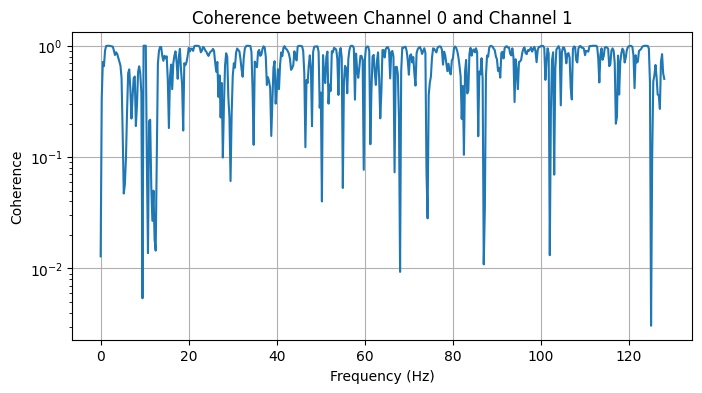

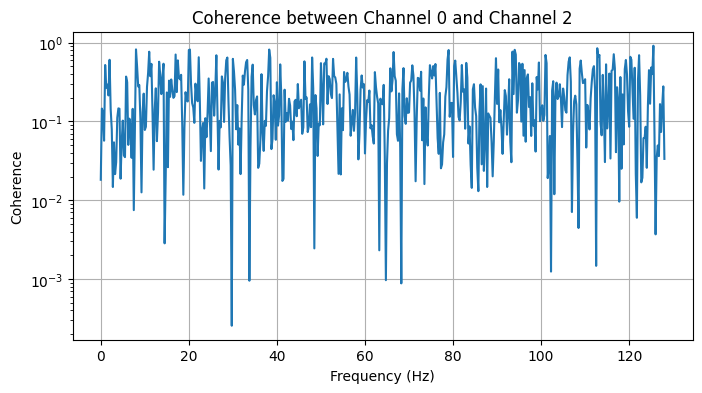

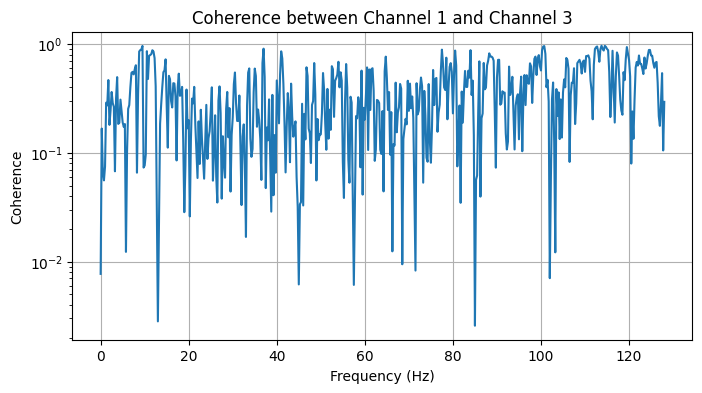

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import coherence, welch

def compute_functional_coherence(eeg_data, fs, channel_pairs):
    """
    Compute and plot the coherence between EEG channel pairs.

    Parameters:
    - eeg_data: ndarray
        A 2D array of shape (n_channels, n_samples), where each row is an EEG channel time series.
    - fs: float
        Sampling frequency of the EEG data (in Hz).
    - channel_pairs: list of tuples
        List of channel index pairs (e.g., [(0, 1), (1, 2)]) to compute coherence.

    Returns:
    - coherence_results: dict
        Dictionary with channel pairs as keys and coherence values as values.
    """
    coherence_results = {}
    
    for ch1, ch2 in channel_pairs:
        # Compute coherence between the two channels
        f, Cxy = coherence(eeg_data[ch1], eeg_data[ch2], fs=fs, nperseg=1024)
        
        # Store the coherence results
        coherence_results[(ch1, ch2)] = (f, Cxy)
        
        # Plot coherence
        plt.figure(figsize=(8, 4))
        plt.semilogy(f, Cxy)
        plt.title(f'Coherence between Channel {ch1} and Channel {ch2}')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Coherence')
        plt.grid(True)
        plt.show()
    
    return coherence_results

# Example Usage
if __name__ == "__main__":
    # Simulated EEG data: 4 channels, 10 seconds of data at 256 Hz
    fs = 256  # Sampling frequency in Hz
    t = np.linspace(0, 10, 10 * fs, endpoint=False)  # Time vector
    eeg_data = np.array([
        np.sin(2 * np.pi * 10 * t),  # Channel 0: 10 Hz sine wave
        np.sin(2 * np.pi * 10 * t + np.pi / 4),  # Channel 1: 10 Hz sine wave, phase-shifted
        np.random.normal(0, 1, len(t)),  # Channel 2: Random noise
        np.sin(2 * np.pi * 20 * t)  # Channel 3: 20 Hz sine wave
    ])
    
    # Define channel pairs to analyze
    channel_pairs = [(0, 1), (0, 2), (1, 3)]
    
    # Compute functional coherence
    coherence_results = compute_functional_coherence(eeg_data, fs, channel_pairs)


## Signal Filtering and Plotting

In [4]:
'''
og_feq - > starting frequency
 - 500 from cgx
downsample_freq -> new frequency
'''

'''

sig = array[i]   # signal (change structure for data)
n_seconds_filter = .1
sig_low = filter_signal(sig, og_feq, 'lowpass', downsample_feq,n_seconds=n_seconds_filter, remove_edges=False) # Lowpass filter
sig_low = sp.signal.resample(sig_low, int((len(sig_low)/og_feq)*downsample_feq))  #downsample
times = np.arange(0, len(sig_low)/downsample_feq, 1/downsample_feq)  #define x-axis (seconds)

# Find the indices corresponding to the start and end time
start_idx = np.searchsorted(times, start_time)
end_idx = np.searchsorted(times, end_time)
windowed_time = times[start_idx:end_idx]
windowed_data = sig_low[start_idx:end_idx]        
# Plot the windowed time series data
plot_time_series(windowed_time, windowed_data, colors = 'b')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Downsampled Time Series Data from {start_time} to {end_time} seconds \n {well_name}, electrode {i},{j}')
plt.show()

#now same thing for the unfiltered, non downsampled data
times = np.arange(0, len(sig)/og_feq, 1/og_feq)
start_idx = np.searchsorted(times, start_time)
end_idx = np.searchsorted(times, end_time)
windowed_time = times[start_idx:end_idx]
windowed_data = sig[start_idx:end_idx]
plot_time_series(windowed_time, windowed_data, colors = 'k')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Time Series Data from {start_time} to {end_time} seconds \n {well_name}, electrode {i},{j}')
plt.show()


'''

"\n\nsig = array[i]   # signal (change structure for data)\nn_seconds_filter = .1\nsig_low = filter_signal(sig, og_feq, 'lowpass', downsample_feq,n_seconds=n_seconds_filter, remove_edges=False) # Lowpass filter\nsig_low = sp.signal.resample(sig_low, int((len(sig_low)/og_feq)*downsample_feq))  #downsample\ntimes = np.arange(0, len(sig_low)/downsample_feq, 1/downsample_feq)  #define x-axis (seconds)\n\n# Find the indices corresponding to the start and end time\nstart_idx = np.searchsorted(times, start_time)\nend_idx = np.searchsorted(times, end_time)\nwindowed_time = times[start_idx:end_idx]\nwindowed_data = sig_low[start_idx:end_idx]        \n# Plot the windowed time series data\nplot_time_series(windowed_time, windowed_data, colors = 'b')\nplt.xlabel('Time (s)')\nplt.ylabel('Amplitude')\nplt.title(f'Downsampled Time Series Data from {start_time} to {end_time} seconds \n {well_name}, electrode {i},{j}')\nplt.show()\n\n#now same thing for the unfiltered, non downsampled data\ntimes = np.

In [6]:
import mne
import numpy as np

def load_eeg_to_array(file_path, file_format="auto"):
    """
    Load raw EEG data and convert it into a 2D NumPy array.

    Parameters:
    - file_path: str
        Path to the .eeg file to be loaded.
    - file_format: str
        Specify the file format ("edf", "brainvision", etc.) or "auto" for auto-detection.

    Returns:
    - eeg_data: ndarray
    - fs: float
    - channel_names: list of str
    """
    try:
        # Attempt auto-detection or force the reader based on the format
        if file_format == "edf":
            raw = mne.io.read_raw_edf(file_path, preload=True)
        elif file_format == "brainvision":
            raw = mne.io.read_raw_brainvision(file_path, preload=True)
        else:
            raw = mne.io.read_raw(file_path, preload=True)

        # Extract data, sampling frequency, and channel names
        eeg_data = raw.get_data()
        fs = raw.info['sfreq']
        channel_names = raw.info['ch_names']

        return eeg_data, fs, channel_names
    except Exception as e:
        raise ValueError(f"Error loading EEG file: {e}")

# Example usage
file_path = "example.eeg"
try:
    eeg_data, fs, channel_names = load_eeg_to_array(file_path, file_format="edf")
except ValueError as error:
    print(error)


Error loading EEG file: Only EDF files are supported, got eeg.


In [12]:
import numpy as np
import pyedflib  # Library for writing EDF files

def convert_eeg_to_edf(input_file, output_file, sfreq, channel_names):
    """
    Convert a raw Cognionics .eeg file to an EDF format.

    Parameters:
    - input_file: str
        Path to the input .eeg file.
    - output_file: str
        Path to the output EDF file.
    - sfreq: float
        Sampling frequency of the data (in Hz).
    - channel_names: list of str
        Names of the channels.

    Returns:
    None
    """
    # Example: Read raw binary data (customize based on Cognionics file structure)
    raw_data = np.fromfile(input_file, dtype=np.float32)  # Assuming binary float32 data

    # Example: Reshape into 2D (n_channels, n_samples) based on known structure
    n_channels = len(channel_names)
    n_samples = len(raw_data) // n_channels
    eeg_data = raw_data.reshape(n_channels, n_samples)

    # Create an EDF writer
    with pyedflib.EdfWriter(output_file, n_channels, file_type=pyedflib.FILETYPE_EDFPLUS) as edf:
        # Set channel metadata
        channel_info = [{
            'label': ch,
            'dimension': 'uV',  # Change to appropriate unit
            'sample_rate': sfreq,
            'physical_min': np.min(eeg_data[i]),
            'physical_max': np.max(eeg_data[i]),
            'digital_min': -32768,
            'digital_max': 32767
        } for i, ch in enumerate(channel_names)]
        edf.setSignalHeaders(channel_info)
        
        # Write each channel's data
        edf.writeSamples(eeg_data)

    print(f"File successfully converted to {output_file}")

# Example Usage
input_file = r"C:\Users\david\Documents\Nocturnal Neuro\Cognionics_timeSeries\HELLOworld.eeg"
output_file = "example.edf"
sampling_freq = 500  # Replace with actual value
channel_names = ["Fp1", "Fp2", "Cz", "Pz", "Oz"]  # Replace with actual channel names
convert_eeg_to_edf(input_file, output_file, sampling_freq, channel_names)


File successfully converted to example.edf


C:\Python312\Lib\site-packages\pyedflib\edfwriter.py:124: UserWarning: Physical minimum for channel 0 (Fp1) is -0.30997034907341003, which has 11 chars, however, EDF+ can only save 8 chars, will be truncated to -0.30997, some loss of precision is to be expected
  warnings.warn('Physical minimum for channel {} ({}) is {}, which has {} chars, '\
C:\Python312\Lib\site-packages\pyedflib\edfwriter.py:124: UserWarning: Physical minimum for channel 1 (Fp2) is -0.3117062449455261, which has 11 chars, however, EDF+ can only save 8 chars, will be truncated to -0.31170, some loss of precision is to be expected
  warnings.warn('Physical minimum for channel {} ({}) is {}, which has {} chars, '\
C:\Python312\Lib\site-packages\pyedflib\edfwriter.py:124: UserWarning: Physical minimum for channel 2 (Cz) is -0.3143731355667114, which has 11 chars, however, EDF+ can only save 8 chars, will be truncated to -0.31437, some loss of precision is to be expected
  warnings.warn('Physical minimum for channel {} 

In [14]:
load_eeg_to_array("example.edf", file_format="auto")

Extracting EDF parameters from C:\Users\david\Documents\Nocturnal Neuro\Signal Analysis\example.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 156999  =      0.000 ...   313.998 secs...


(array([[ 8.62060166e-09, -1.93412463e-07,  2.79272480e-09, ...,
          8.50099184e-10,  8.50099184e-10,  8.50099184e-10],
        [ 2.43787991e-08,  8.83758297e-09,  6.89493095e-09, ...,
          1.06697490e-09,  1.06697490e-09,  1.06697490e-09],
        [ 1.39450764e-08,  3.14293112e-08,  6.05697026e-08, ...,
          3.46227054e-10,  3.46227054e-10,  3.46227054e-10],
        [ 1.19273220e-08,  1.96978599e-08,  3.52389357e-08, ...,
          2.71515221e-10,  2.71515221e-10,  2.71515221e-10],
        [ 9.80454658e-08,  1.27187512e-07,  1.02670534e-06, ...,
          9.05311666e-10,  9.05311666e-10,  9.05311666e-10]]),
 500.0,
 ['Fp1', 'Fp2', 'Cz', 'Pz', 'Oz'])